<a href="https://colab.research.google.com/github/shahbaz11-arch/NNDDE/blob/main/Problem_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Discovered Probabilistic Hermite Weights ---
w0: -0.53672521
w1: 1.17856397
w2: -0.41435754
w3: -0.02978213
w4: 0.06254785
w5: -0.02197800
w6: 0.00476394
w7: -0.00058819
w8: 0.00005889

--- Solution Evaluation (10 Test Points) ---
x     | y_approx     | y_exact (xe^-x) | Relative Error 
-------------------------------------------------------
0.000 | -0.00000000  | 0.00000000      | 5.5511e-16     
0.111 | 0.10387998   | 0.09942659      | 4.4791e-02     
0.222 | 0.19400343   | 0.17794165      | 9.0264e-02     
0.333 | 0.27142326   | 0.23884377      | 1.3641e-01     
0.444 | 0.33717408   | 0.28496906      | 1.8320e-01     
0.556 | 0.39226124   | 0.31875190      | 2.3062e-01     
0.667 | 0.43765264   | 0.34227808      | 2.7865e-01     
0.778 | 0.47427253   | 0.35733120      | 3.2726e-01     
0.889 | 0.50299734   | 0.36543315      | 3.7644e-01     
1.000 | 0.52465290   | 0.36787944      | 4.2615e-01     


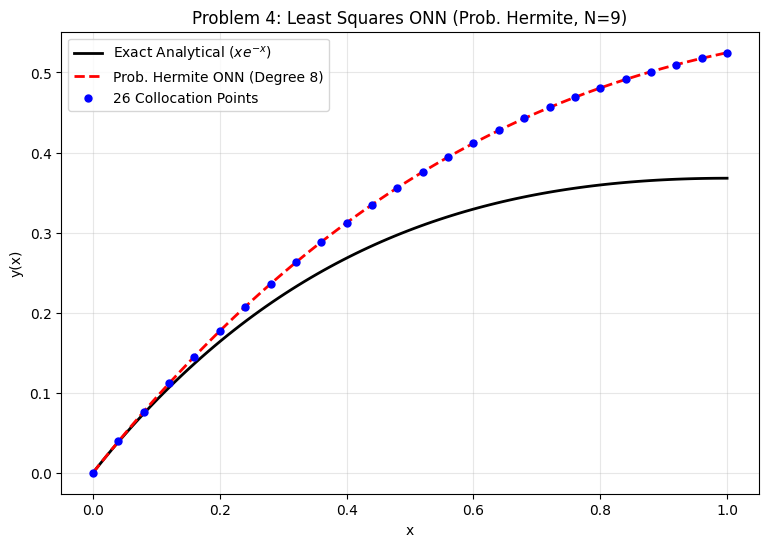

In [24]:
#Problem--4 ( Hermite)
import torch
import matplotlib.pyplot as plt

# ==========================================
# 1. Probabilistic Hermite Basis Implementation
# ==========================================
def get_prob_hermite_basis(x, n_polys):
    """
    Generates Probabilistic Hermite polynomials He_n(x) and their derivatives He'_n(x)
    using standard recurrence relations for n = 0 to n_polys-1.
    """
    if x.dim() == 0:
        x = x.unsqueeze(0)

    num_points = len(x)
    He = torch.zeros(num_points, n_polys, dtype=torch.float64)
    He_d = torch.zeros(num_points, n_polys, dtype=torch.float64)

    # Base Case: n=0 -> He_0 = 1, He'_0 = 0
    He[:, 0] = 1.0

    if n_polys > 1:
        # Base Case: n=1 -> He_1 = x, He'_1 = 1
        He[:, 1] = x
        He_d[:, 1] = 1.0

    # Recurrence Loop for n >= 2
    for n in range(2, n_polys):
        He[:, n] = x * He[:, n-1] - (n - 1.0) * He[:, n-2]
        He_d[:, n] = float(n) * He[:, n-1]

    return He, He_d

# ==========================================
# 2. Problem Setup (Overdetermined Linear NDDE)
# ==========================================
N_POLYS = 9
NUM_COLLOC_POINTS = 26

# Create 20 evenly spaced collocation points between 0 and 1
points_colloc = torch.linspace(0.0, 1.0, NUM_COLLOC_POINTS, dtype=torch.float64)

# Initialize Overdetermined System (21 equations, 7 unknowns)
num_equations = NUM_COLLOC_POINTS + 1
A = torch.zeros(num_equations, N_POLYS, dtype=torch.float64)
b = torch.zeros(num_equations, 1, dtype=torch.float64)

# --- Row 0: Initial Condition y(0) = 0 ---
He_0, _ = get_prob_hermite_basis(torch.tensor([0.0], dtype=torch.float64), N_POLYS)
A[0, :] = He_0
b[0, 0] = 0.0

# --- Rows 1-20: ODE Constraints at Collocation Points ---
for i, x_val in enumerate(points_colloc):
    x = torch.tensor([x_val], dtype=torch.float64)

    # 1. Compute delayed argument
    delay_x = 0.80 * x

    # 2. Evaluate basis at current and delayed arguments
    He_x, Hed_x = get_prob_hermite_basis(x, N_POLYS)
    He_delay, Hed_delay = get_prob_hermite_basis(delay_x, N_POLYS)

    # 3. Construct LHS (Coefficients for w_n)
    # y'(x) - 0.5y'(0.80x) - 0.10y(0.80x) + y(x)
    coeffs = Hed_x - 0.50 * Hed_delay - 0.10 * He_delay + He_x
    A[i+1, :] = coeffs

    # 4. Construct RHS
    # (0.80x - 0.50)e^{-0.80x} + e^{-x}
    rhs = (0.80 * x - 0.50) * torch.exp(-0.80 * x) + torch.exp(-x)
    b[i+1, 0] = rhs

# ==========================================
# 3. Solve for Weights (Least Squares)
# ==========================================
# We use torch.linalg.lstsq to find the optimal weights for the overdetermined system
solution = torch.linalg.lstsq(A, b)
weights = solution.solution

print("--- Discovered Probabilistic Hermite Weights ---")
for i in range(N_POLYS):
    print(f"w{i}: {weights[i].item():.8f}")

# ==========================================
# 4. Evaluate Solution and Relative Error
# ==========================================
print("\n--- Solution Evaluation (10 Test Points) ---")
print(f"{'x':<5} | {'y_approx':<12} | {'y_exact (xe^-x)':<15} | {'Relative Error':<15}")
print("-" * 55)

x_eval = torch.linspace(0, 1, 10, dtype=torch.float64)
He_eval, _ = get_prob_hermite_basis(x_eval, N_POLYS)

y_approx = (He_eval @ weights).flatten()
y_exact = x_eval * torch.exp(-x_eval)

# Compute relative error (handle x=0 separately to avoid division by zero)
rel_errors = torch.zeros_like(x_eval)
for i in range(len(x_eval)):
    if x_eval[i] == 0:
        rel_errors[i] = torch.abs(y_approx[i] - y_exact[i])
    else:
        rel_errors[i] = torch.abs(y_approx[i] - y_exact[i]) / torch.abs(y_exact[i])

for i in range(len(x_eval)):
    x_val = x_eval[i].item()
    approx_val = y_approx[i].item()
    exact_val = y_exact[i].item()
    error_val = rel_errors[i].item()
    print(f"{x_val:<5.3f} | {approx_val:<12.8f} | {exact_val:<15.8f} | {error_val:<15.4e}")

# Visualization
plt.figure(figsize=(9, 6))

# Plot analytical solution using a fine grid
x_fine = torch.linspace(0, 1, 100, dtype=torch.float64)
y_fine_exact = x_fine * torch.exp(-x_fine)
plt.plot(x_fine.numpy(), y_fine_exact.numpy(), 'k-', linewidth=2, label='Exact Analytical ($x e^{-x}$)')

# Plot approximation
He_fine, _ = get_prob_hermite_basis(x_fine, N_POLYS)
y_fine_approx = (He_fine @ weights).flatten()
plt.plot(x_fine.numpy(), y_fine_approx.numpy(), 'r--', linewidth=2, label=f'Prob. Hermite ONN (Degree {N_POLYS-1})')

# Scatter collocation points
plt.scatter(points_colloc.numpy(), (get_prob_hermite_basis(points_colloc, N_POLYS)[0] @ weights).flatten().numpy(),
            color='blue', zorder=5, s=25, label=f'{NUM_COLLOC_POINTS} Collocation Points')

plt.title(f"Problem 4: Least Squares ONN (Prob. Hermite, N={N_POLYS})")
plt.xlabel("x")
plt.ylabel("y(x)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()